STATISTICAL TESTS

Conversion rate — A: 0.0937 | B: 0.1103 | Lift: +0.0166
Z-score: 2.744 | P-value: 0.0061
=> Statistically significant

Revenue (converted users) — A mean: 29.82 | B mean: 30.29
T-statistic: -0.346 | P-value: 0.7295

Charts saved to ab_test_charts.png

MACHINE LEARNING: Conversion Prediction Model

Model AUC: 0.567

Classification report:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95      2245
           1       0.00      0.00      0.00       255

    accuracy                           0.90      2500
   macro avg       0.45      0.50      0.47      2500
weighted avg       0.81      0.90      0.85      2500


Feature coefficients (log-odds impact on conversion):
           feature  coefficient
      cat__group_B     0.203841
    remainder__dow    -0.036163
cat__device_mobile    -0.345315
cat__device_tablet    -0.383657

UPLIFT MODELING: Estimating Heterogeneous Treatment Effects

Estimated uplift (treatment effect) b

c:\Users\amrel\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\amrel\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\amrel\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



Uplift chart saved to uplift_distribution.png

Done. Outputs: ab_test_charts.png, uplift_distribution.png


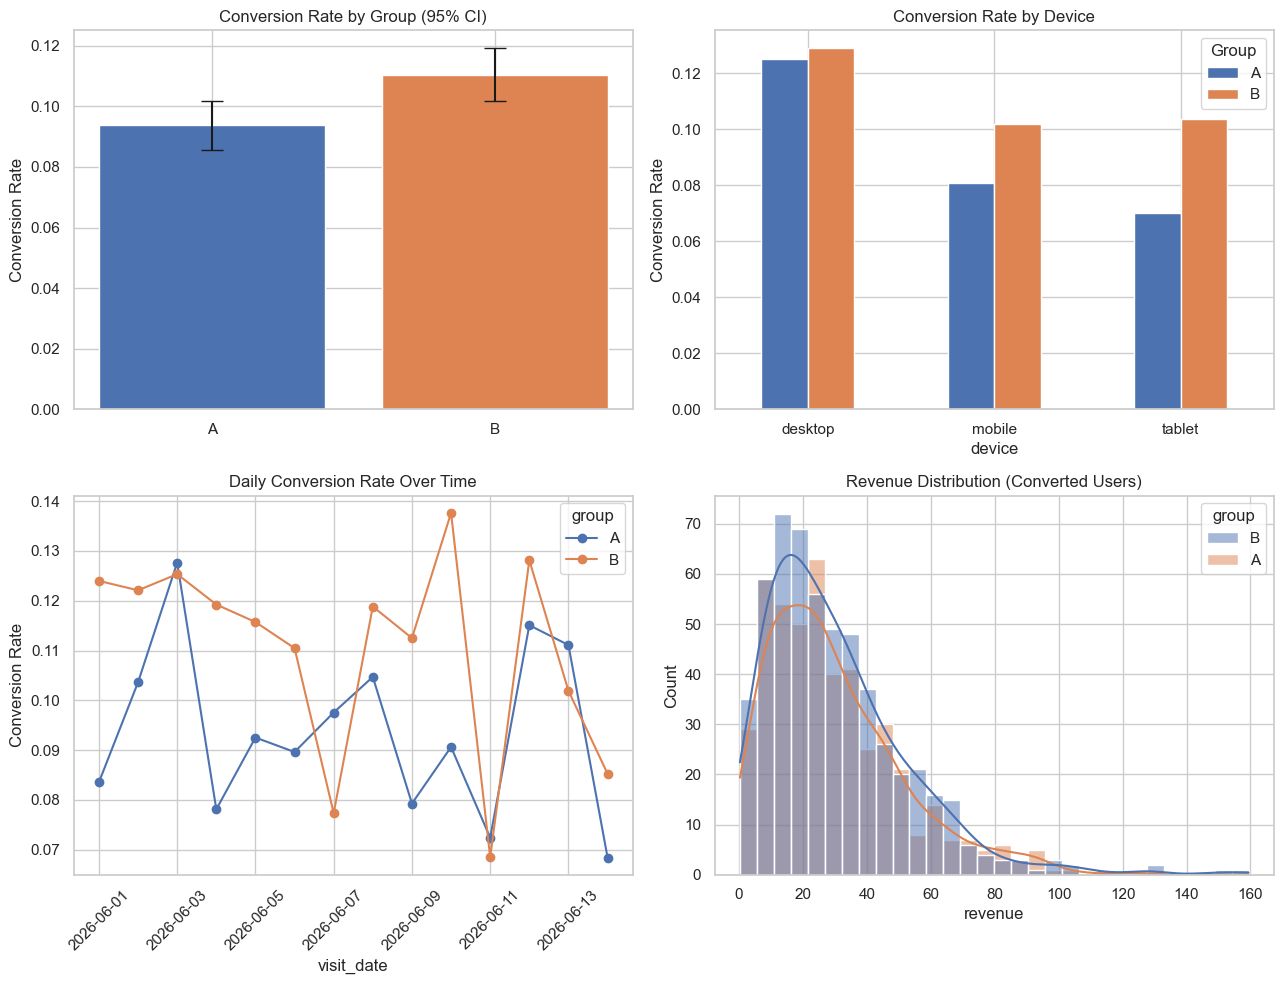

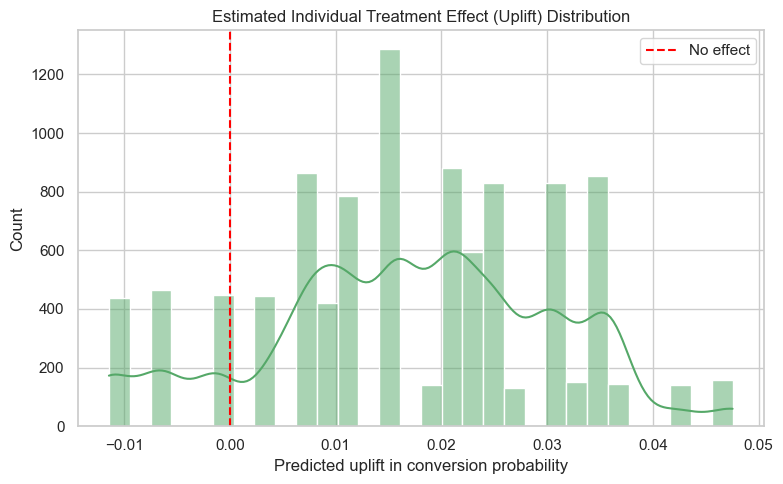

In [2]:
"""
A/B Test Analysis: Statistics + Charts + Machine Learning

Loads ab_test_data.csv and:
1. Runs statistical significance tests (z-test for proportions, t-test for revenue)
2. Produces visualizations (conversion by group, by device, over time, revenue distribution)
3. Trains a logistic regression model to predict conversion from user features
4. Builds a simple uplift model (T-learner) to estimate which segments respond
   best to the treatment
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report

sns.set_theme(style="whitegrid")

# ---- Load data ----
df = pd.read_csv("ab_test_data.csv", parse_dates=["visit_date"])

# =========================================================
# 1. STATISTICAL SIGNIFICANCE TESTING
# =========================================================
print("=" * 60)
print("STATISTICAL TESTS")
print("=" * 60)

a = df[df.group == "A"]
b = df[df.group == "B"]

# Two-proportion z-test for conversion rate
conv_a, n_a = a.converted.sum(), len(a)
conv_b, n_b = b.converted.sum(), len(b)
p_a, p_b = conv_a / n_a, conv_b / n_b
p_pool = (conv_a + conv_b) / (n_a + n_b)
se = np.sqrt(p_pool * (1 - p_pool) * (1 / n_a + 1 / n_b))
z = (p_b - p_a) / se
p_value_z = 2 * (1 - stats.norm.cdf(abs(z)))

print(f"\nConversion rate — A: {p_a:.4f} | B: {p_b:.4f} | Lift: {p_b - p_a:+.4f}")
print(f"Z-score: {z:.3f} | P-value: {p_value_z:.4f}")
print("=> Statistically significant" if p_value_z < 0.05 else "=> Not statistically significant")

# T-test for revenue (only converted users, to compare order value)
t_stat, p_value_t = stats.ttest_ind(
    a[a.converted == 1].revenue, b[b.converted == 1].revenue, equal_var=False
)
print(f"\nRevenue (converted users) — A mean: {a[a.converted==1].revenue.mean():.2f} "
      f"| B mean: {b[b.converted==1].revenue.mean():.2f}")
print(f"T-statistic: {t_stat:.3f} | P-value: {p_value_t:.4f}")

# =========================================================
# 2. VISUALIZATIONS
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Conversion rate by group with CI error bars
conv_rates = df.groupby("group")["converted"].agg(["mean", "count"])
conv_rates["se"] = np.sqrt(conv_rates["mean"] * (1 - conv_rates["mean"]) / conv_rates["count"])
axes[0, 0].bar(conv_rates.index, conv_rates["mean"], yerr=1.96 * conv_rates["se"],
               capsize=8, color=["#4C72B0", "#DD8452"])
axes[0, 0].set_title("Conversion Rate by Group (95% CI)")
axes[0, 0].set_ylabel("Conversion Rate")

# Conversion rate by device and group
device_conv = df.groupby(["device", "group"])["converted"].mean().unstack()
device_conv.plot(kind="bar", ax=axes[0, 1], color=["#4C72B0", "#DD8452"])
axes[0, 1].set_title("Conversion Rate by Device")
axes[0, 1].set_ylabel("Conversion Rate")
axes[0, 1].legend(title="Group")
axes[0, 1].tick_params(axis="x", rotation=0)

# Daily conversion rate trend over the test period
daily = df.groupby([df.visit_date.dt.date, "group"])["converted"].mean().unstack()
daily.plot(ax=axes[1, 0], marker="o", color=["#4C72B0", "#DD8452"])
axes[1, 0].set_title("Daily Conversion Rate Over Time")
axes[1, 0].set_ylabel("Conversion Rate")
axes[1, 0].tick_params(axis="x", rotation=45)

# Revenue distribution (converted users only)
sns.histplot(data=df[df.converted == 1], x="revenue", hue="group", bins=30,
             kde=True, ax=axes[1, 1], palette=["#4C72B0", "#DD8452"])
axes[1, 1].set_title("Revenue Distribution (Converted Users)")

plt.tight_layout()
plt.savefig("ab_test_charts.png", dpi=150)
print("\nCharts saved to ab_test_charts.png")

# =========================================================
# 3. MACHINE LEARNING: Predict conversion from user features
# =========================================================
print("\n" + "=" * 60)
print("MACHINE LEARNING: Conversion Prediction Model")
print("=" * 60)

df["dow"] = df.visit_date.dt.dayofweek
features = ["group", "device", "dow"]
X = df[features]
y = df["converted"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(drop="first"), ["group", "device"])],
    remainder="passthrough"
)

model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nModel AUC: {auc:.3f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred))

# Feature coefficients (interpretability)
encoded_names = model.named_steps["preprocess"].get_feature_names_out()
coefs = model.named_steps["classifier"].coef_[0]
coef_df = pd.DataFrame({"feature": encoded_names, "coefficient": coefs}).sort_values(
    "coefficient", ascending=False
)
print("\nFeature coefficients (log-odds impact on conversion):")
print(coef_df.to_string(index=False))

# =========================================================
# 4. UPLIFT MODELING (T-Learner): who benefits most from treatment?
# =========================================================
print("\n" + "=" * 60)
print("UPLIFT MODELING: Estimating Heterogeneous Treatment Effects")
print("=" * 60)

feature_cols = ["device", "dow"]
X_all = pd.get_dummies(df[feature_cols], drop_first=True)

# Train separate models on treatment and control groups (T-learner)
model_control = LogisticRegression(max_iter=1000).fit(
    X_all[df.group == "A"], df.loc[df.group == "A", "converted"]
)
model_treatment = LogisticRegression(max_iter=1000).fit(
    X_all[df.group == "B"], df.loc[df.group == "B", "converted"]
)

# Predict counterfactual conversion probability for every user under both scenarios
prob_if_control = model_control.predict_proba(X_all)[:, 1]
prob_if_treatment = model_treatment.predict_proba(X_all)[:, 1]
df["uplift"] = prob_if_treatment - prob_if_control

print("\nEstimated uplift (treatment effect) by device segment:")
print(df.groupby("device")["uplift"].mean().sort_values(ascending=False))

# Plot uplift distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["uplift"], bins=30, kde=True, color="#55A868")
plt.axvline(0, color="red", linestyle="--", label="No effect")
plt.title("Estimated Individual Treatment Effect (Uplift) Distribution")
plt.xlabel("Predicted uplift in conversion probability")
plt.legend()
plt.tight_layout()
plt.savefig("uplift_distribution.png", dpi=150)
print("\nUplift chart saved to uplift_distribution.png")

print("\nDone. Outputs: ab_test_charts.png, uplift_distribution.png")